# Analisis Data Tomato-LeafGuard


## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana kombinasi suhu dan kelembapan memengaruhi jumlah macam-macam penyakit daun tomat?
- **Pertanyaan 2:** Bagaimana jumlah nitrogen dalam tanah berpengaruh terhadap sepuluh jenis penyakit daun tomat?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
file_id = '1IgmoVynytjxlEVYENSTSkQ2pUbB86jzd'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(url)

print(df.head())

     id         disease  temperature  humidity   residue  nutrient
0  5705    early blight         19.0      60.0     light     114.0
1  7996    early blight         28.0      83.0     heavy      98.0
2  6185  bacterial spot         25.0      89.0     light     142.0
3  5254       leaf mold         24.0      91.0  moderate     139.0
4  9608         healthy         14.0      77.0     light     147.0


**Insight:**
- Dataset ini berisi data dari berbagai kebun tomat dan permasalahan yang dihadapai di masing-masing kebun.
- Dataset berisi kolom-kolom berikut: `id` id kebun, `disease` jenis penyakit yang ditemukan, `temperature` suhu rata-rata kebun dalam derajat Celsius, `humidity` presentase kelembapan kebun, `residue` residue tanaman sebelumnya/gulma dalam tiga kategori, `nutrient` kadar nitrogen dalam tanah (Kg/ha).

### Assessing Data

#### Identifying ... problem

In [3]:
# Mengidentifikasi isi dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1000 non-null   int64  
 1   disease      1000 non-null   object 
 2   temperature  956 non-null    float64
 3   humidity     953 non-null    float64
 4   residue      969 non-null    object 
 5   nutrient     950 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 47.0+ KB


In [4]:
df.isna().sum()

,0
id,0
disease,0
temperature,44
humidity,47
residue,31
nutrient,50


In [5]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  82


**Insight:**
- Terdapat total 150 nilai yang kosong (missing values).
- terdapat total 105 data duplikat.

**Steps to Take:**
- Mengisi missing values untuk mengurangi kehilangan data.
- Menghapus row dengan duplicates.


### Cleaning Data

#### Fixing ... problem

In [6]:
# Mengisi kolom numerik dengan mean
kolom_numerik = ['temperature', 'humidity', 'nutrient']

for col in kolom_numerik:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[kolom_numerik] = df[kolom_numerik].fillna(df[kolom_numerik].mean())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1000 non-null   int64  
 1   disease      1000 non-null   object 
 2   temperature  1000 non-null   float64
 3   humidity     1000 non-null   float64
 4   residue      969 non-null    object 
 5   nutrient     1000 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 47.0+ KB


In [7]:
# Menghapus sisa baris yang memiliki nilai kosong
df = df.dropna()

In [8]:
# Menghapus data dupilkat
df = df.drop_duplicates()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 887 entries, 0 to 998
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           887 non-null    int64  
 1   disease      887 non-null    object 
 2   temperature  887 non-null    float64
 3   humidity     887 non-null    float64
 4   residue      887 non-null    object 
 5   nutrient     887 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 48.5+ KB


**Insight:**
Jumlah data setelah dibersihkan berkurang menjadi sebanyak 848 baris.

## Exploratory Data Analysis (EDA)

### Explore ...

In [10]:
df.describe(include="all")

,id,disease,temperature,humidity,residue,nutrient
count,887.000000,887,887.000000,887.000000,887,887.000000
unique,NaN,10,NaN,NaN,3,NaN
top,NaN,spider mites or two spotted spider mites,NaN,NaN,moderate,NaN
freq,NaN,102,NaN,NaN,449,NaN
mean,5441.191657,NaN,22.781719,83.614631,NaN,137.347068
std,2642.979761,NaN,5.076991,13.376004,NaN,14.862595
min,1003.000000,NaN,11.000000,45.000000,NaN,97.000000
25%,3033.000000,NaN,19.000000,82.000000,NaN,129.000000
50%,5521.000000,NaN,23.000000,89.000000,NaN,137.577895
75%,7816.000000,NaN,27.000000,93.000000,NaN,145.000000


In [11]:
# Melihat proporsi setiap penyakit dalam dataset
df['disease'].value_counts(normalize=True)

,proportion
disease,
spider mites or two spotted spider mites,0.114994
early blight,0.110485
septoria leaf spot,0.105975
mosaic virus,0.102593
leaf mold,0.102593
late blight,0.100338
yellow leaf curl virus,0.099211
healthy,0.094701
target spot,0.089064


In [12]:
# Rata-rata suhu pada tiap-tiap penyakit
df.groupby('disease')['temperature'].mean()

,temperature
disease,
bacterial spot,26.385173
early blight,26.647724
healthy,19.813658
late blight,20.825584
leaf mold,21.841372
mosaic virus,19.605821
septoria leaf spot,21.410264
spider mites or two spotted spider mites,28.752769
target spot,20.776548


In [13]:
# Rata-rata kelembapan pada tiap-tiap penyakit
df.groupby('disease')['humidity'].mean()

,humidity
disease,
bacterial spot,87.069551
early blight,86.989164
healthy,72.017489
late blight,92.695934
leaf mold,88.933386
mosaic virus,87.510649
septoria leaf spot,93.172378
spider mites or two spotted spider mites,54.491585
target spot,86.793324


In [14]:
df.groupby('disease')['nutrient'].mean()

,nutrient
disease,
bacterial spot,138.738977
early blight,112.831300
healthy,137.523810
late blight,136.742082
leaf mold,137.473025
mosaic virus,135.469601
septoria leaf spot,138.295039
spider mites or two spotted spider mites,162.167110
target spot,136.951339


In [15]:
# Jumlah penyakit pada kategori residue
jumlah_disease = df.groupby('residue')['disease'].value_counts()
print(jumlah_disease)

residue   disease                                 
heavy     early blight                                59
          yellow leaf curl virus                      42
          mosaic virus                                36
          target spot                                 35
          leaf mold                                   34
          bacterial spot                               2
          spider mites or two spotted spider mites     2
          healthy                                      1
          late blight                                  1
          septoria leaf spot                           1
light     spider mites or two spotted spider mites    52
          septoria leaf spot                          46
          late blight                                 45
          healthy                                     36
          bacterial spot                              35
          yellow leaf curl virus                       4
          mosaic virus               

**Insight:**
- proporsi data setiap jenis penyakit kurang lebih seimbang dengan porsi paling besar pada spider mites and two spotted spider mites sebanyyak 11,4% dari data dan porsi paling kecil pada yellow leaf curl virus sebesar 8% dari data.
- penyakit berdasarkan rata-rata suhu menunjukkan data tomat berkisar di rata-rata suhu 19°C hingga 28°C.
- penyakit berdasarkan rata-rata kelembapan menunjukkan range yang luas dari 54% hingga 93% rata-rata kelembapan.
- penyakit berdasarkan rata-rata kandungan nitrogen menunjukkan range dari 112 hingga 162 kg/ha.
- penyakit berdasarkan residu kebun menunjukkan persebaran yang merata dan berpusat di tingkat residu moderate.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

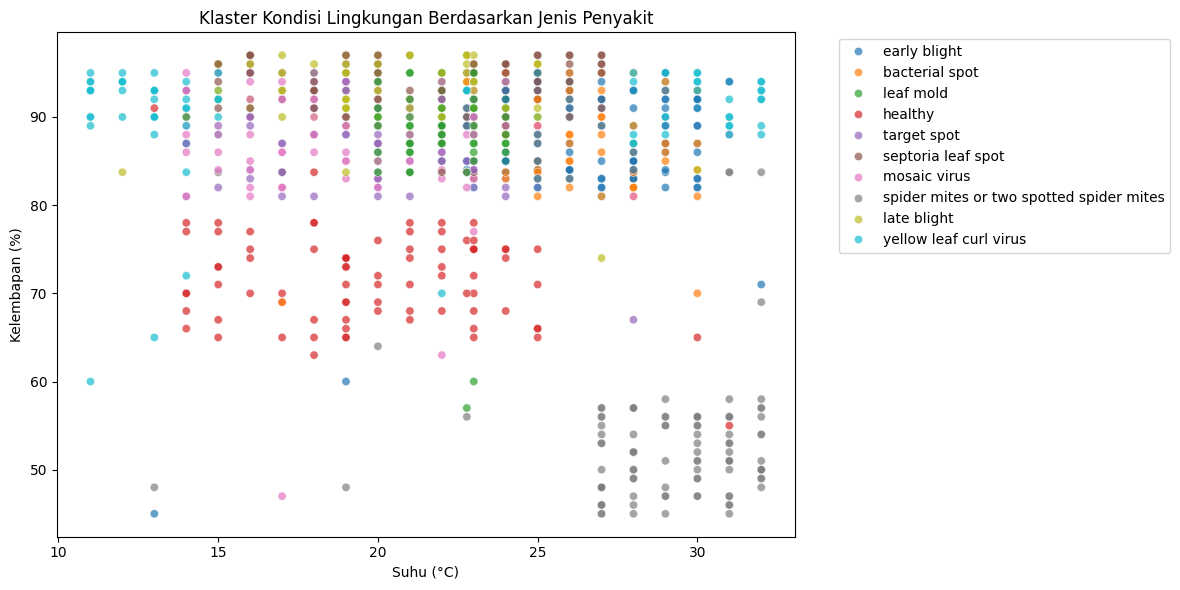

In [16]:
plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x='temperature', y='humidity', hue='disease', palette='tab10', alpha=0.7)

plt.title('Klaster Kondisi Lingkungan Berdasarkan Jenis Penyakit')
plt.xlabel('Suhu (°C)')
plt.ylabel('Kelembapan (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Pertanyaan 2:

/tmp/ipykernel_160250/238526027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='nutrient', y='disease', palette='vlag', orient='h')


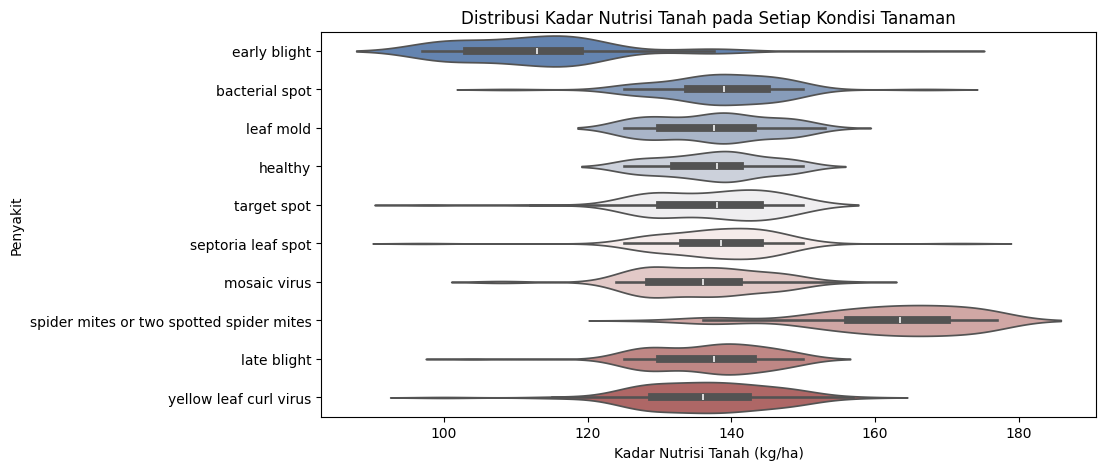

In [17]:
plt.figure(figsize=(10, 5))

sns.violinplot(data=df, x='nutrient', y='disease', palette='vlag', orient='h')

plt.title('Distribusi Kadar Nutrisi Tanah pada Setiap Kondisi Tanaman')
plt.xlabel('Kadar Nutrisi Tanah (kg/ha)')
plt.ylabel('Penyakit')
plt.show()


**Insight:**
- **Pertanyaan 1: Bagaimana kombinasi suhu dan kelembapan memengaruhi jumlah macam-macam penyakit daun tomat?**
Berdasarkan visualisasi yang telah dibuat, tanaman tomat yang sehat tumbuh dengan suhu sekitar 15°C hingga 25°C. Suhu tinggi diatas 25°C beresiko tinggi menyebabkan tanaman tomat memiliki penyakit spider mites atau two spotted spider mites. Suhu ekstrem dibawah 15°C dan diatas 25°C juga meningkatkan kemungkinan penyakit yellow leave curl virus. Penyakit lain timbul di rentang suhu yang normal dan mirip dengan tomat sehat. Perbedaan dapat dilihat dari kelembapan kebun.
Tomat sehat tumbuh dengan presentase kelembapan berkisar di antara 65% hingga 78%. Kelembapan rendah di bawah 58% meningkatkan resiko penyakit spider mites atau two spotted spider mites. Kelembapan tinggi diatas 80% meningkatkan resiko banyak penyakit yaitu bacterial spot, early blight, late blight, leaf mold, target spot, septoria leaf spot, mosaic virus, dan yellow leave curl virus.
- **Pertanyaan 2: Bagaimana jumlah nitrogen dalam tanah berpengaruh terhadap jenis-jenis penyakit daun tomat?**
Dari visualisasi yang telah dibuat, kebanyakan kondisi tanaman tumbuh dengan kadar nitrogen dalam tanah yang normal dengan kisaran 125-150 kg/ha. Pengecualian terjadi pada tanaman dengan penyakit early blight dan spider mites and two spotted spider mites. Early blight banyak ditemukan pada tanaman yang tumbuh dengan kadar nitrogen dalam tanah yang rendah pada 90-120 kg/ha. Sedangkan spider mites and two spotted spider mites banyak ditemukan pada kadar nitrogen dalam tanah sekitar 145-190 kg/ha

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** **Bagaimana kombinasi suhu dan kelembapan memengaruhi jumlah macam-macam penyakit daun tomat?**
Suhu rata-rata kebun optimal untuk tomat adalah sekitar 15°C-25°C. Suhu ekstrem meningkatkan resiko beberapa penyakit. Kelembapan yang baik untuk tanaman tomat tumbuh sehat ada di sekitar 65%-78%. Kelembapan yang tinggi meningkatkan resiko banyak penyakit tanaman.
- **Conclusion pertanyaan 2:** **Bagaimana jumlah nitrogen dalam tanah berpengaruh terhadap jenis-jenis penyakit daun tomat?**
Kadar nitrogen dalam tanah yang baik untuk tomat adalah sekitar 125-150 kg/ha. Kadar nitrogen tanah yang terlalu tinggi atau rendah dapat meningkatkan resiko early blight atau spider mites and two spotted spider mites.

**Rekomendasi Action Item:**
- **Pertanyaan 1: Bagaimana kombinasi suhu dan kelembapan memengaruhi jumlah macam-macam penyakit daun tomat?**
Petani dapat melakukan penyesuaian suhu kebun dengan cara menerapkan peneduh dan juga menerapkan sistem ventilasi. untuk mengatasi masalah kelembapan berlebih, petani dapat melebarkan jarak tanam, mengurangi frekuensi penyiraman, mengurangi jumlah reside tanaman sebelumnya, dan mengurangi jumlah gulma.
- **Pertanyaan 2: Bagaimana jumlah nitrogen dalam tanah berpengaruh terhadap jenis-jenis penyakit daun tomat?**
Jika petani mendapati tanamannya terdapat early blight atau spider mites dan two spotted spider mites ada kemungkinan kadar nitrogen dalam tanah kebun tidak sesuai. Untuk mengatasi kadar nitrogen yang terlalu rendah, petani dapat menggunakan kompos, pupuk organik ataupun pupuk kimia. UNtuk mengatasi kadar nitrogen yang terlalu tinggi, petani dapat melakukan pembilasan ataupun menggunakan bahan kaya karbon.